In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

In [16]:
data=pd.read_csv(r'D:\Priya python and data science\Data Analysis\Capstone project\Healthcare\diabetic_data.csv')
data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [20]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [21]:
data.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [30]:
#Perform descriptive statistical analysis for numerical features
num_cols=data.select_dtypes(include=['int64','float64'])
num_cols=num_cols.drop(columns=['encounter_id','patient_nbr','admission_type_id','discharge_disposition_id','admission_source_id'])
num_cols.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


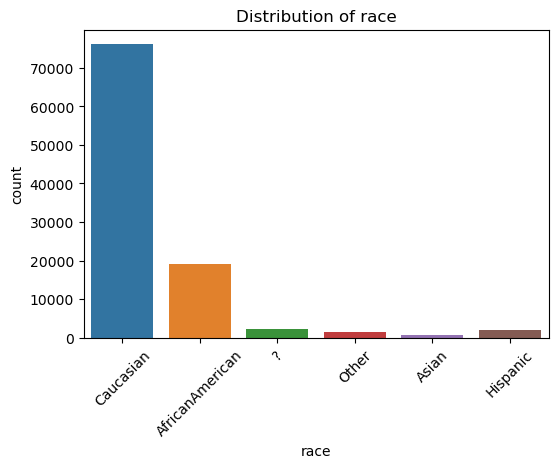

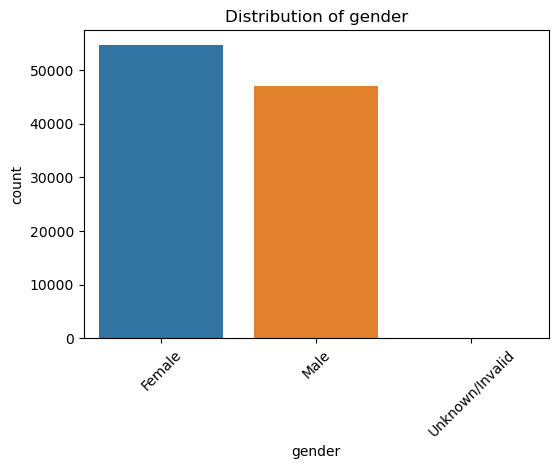

In [37]:
#Visualize the distribution of categorical features - race and gender
cat_cols=['race','gender']
for col in cat_cols:
    plt.figure(figsize=[6,4])
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

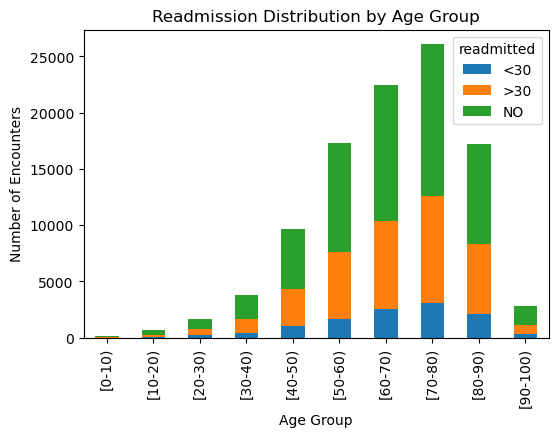

In [54]:
#Explore the relationship between readmission status and age
age_readmit = data.groupby(['age', 'readmitted']).size().unstack()
age_readmit.plot(kind='bar',stacked=True,figsize=(6,4))
plt.title("Readmission Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")
plt.show()

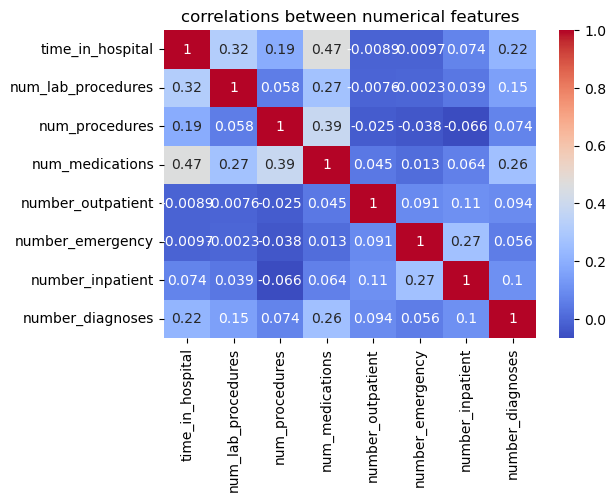

In [59]:
#Investigate correlations between numerical features
corr_matrix=num_cols.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('correlations matrix of numerical features')
plt.show()

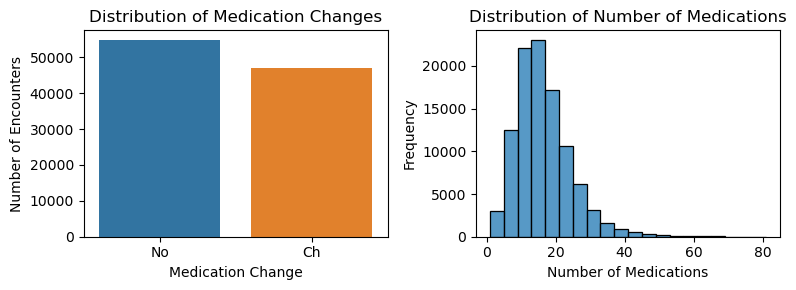

In [94]:
#Analyze the distribution of medication changes and total medications taken
#distribution of medication changes
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.countplot(data=data,x='change')
plt.title("Distribution of Medication Changes")
plt.xlabel("Medication Change")
plt.ylabel("Number of Encounters")
#distribution of total medications taken
plt.subplot(1, 2, 2)
sns.histplot(data['num_medications'],bins=20)
plt.title("Distribution of Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

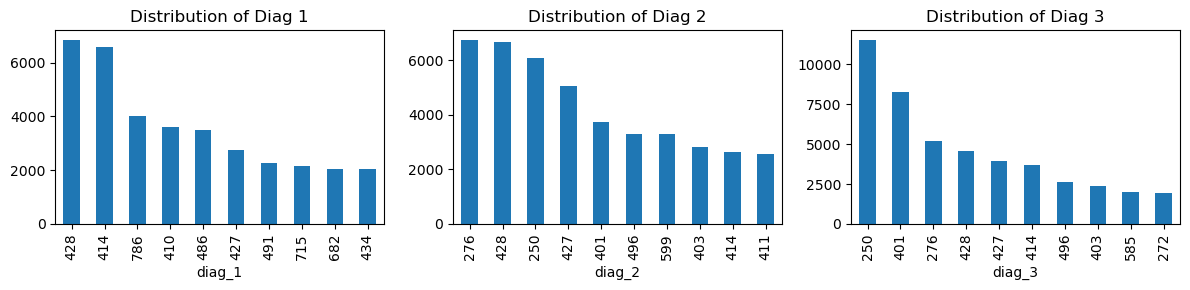

In [114]:
#Examine the distribution of diagnoses categories
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
data['diag_1'].value_counts().head(10).plot(kind='bar')
plt.title("Distribution of Diag 1")
plt.subplot(1,3,2)
data['diag_2'].value_counts().head(10).plot(kind='bar')
plt.title("Distribution of Diag 2")
plt.subplot(1,3,3)
data['diag_3'].value_counts().head(10).plot(kind='bar')
plt.title("Distribution of Diag 3")

plt.tight_layout()
plt.show()



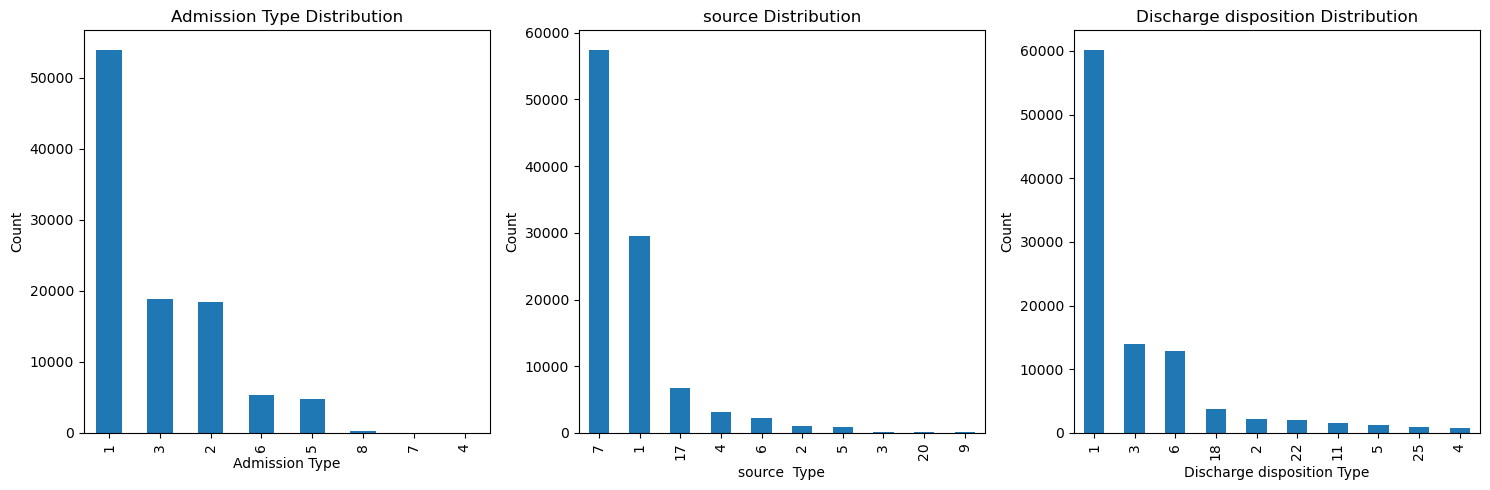

In [139]:
#Explore the distribution of patients across admission types, sources, and discharge disposition
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
data['admission_type_id'].value_counts().head(10).plot(kind='bar')
plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.subplot(1,3,2)
data['admission_source_id'].value_counts().head(10).plot(kind='bar')
plt.title("source Distribution")
plt.xlabel("source  Type")
plt.ylabel("Count")
plt.subplot(1,3,3)
data['discharge_disposition_id'].value_counts().head(10).plot(kind='bar')
plt.title("Discharge disposition Distribution")
plt.xlabel("Discharge disposition Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



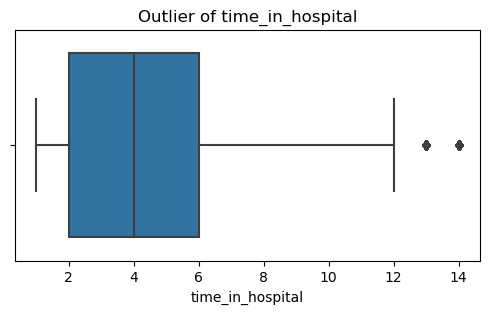

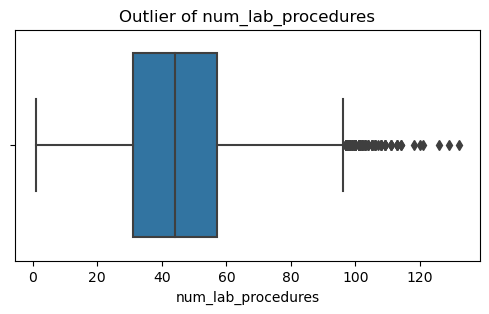

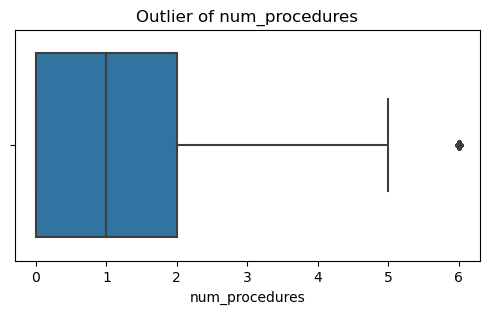

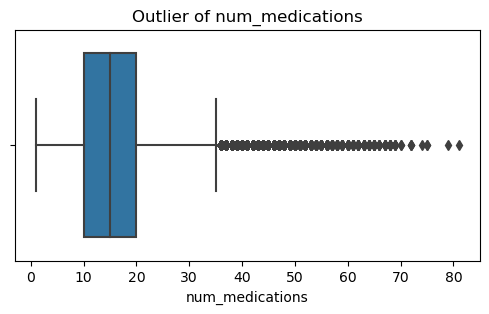

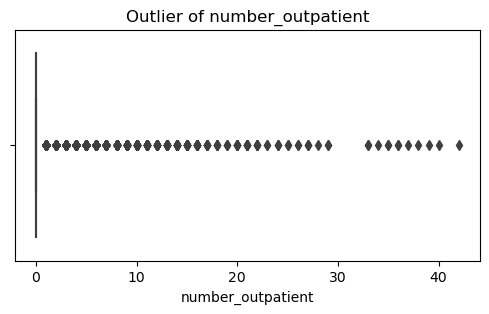

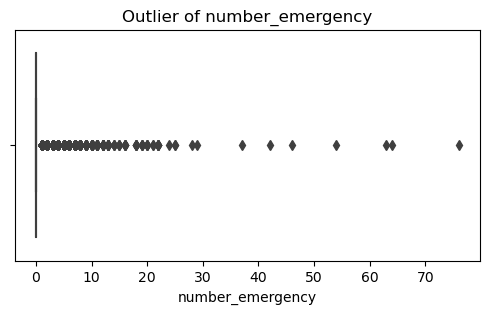

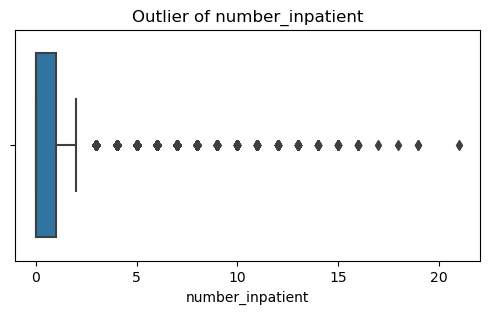

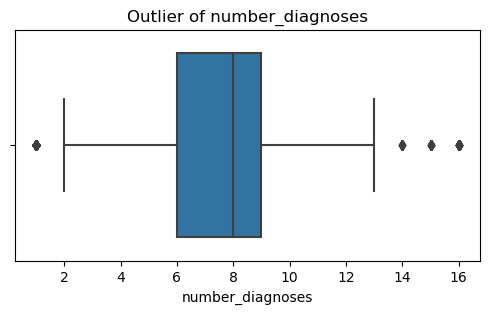

In [150]:
#Identify and visualize any outliers in the dataset, especially in numerical features
for i in num_cols.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=num_cols[i])
    plt.title(f'Outlier of {i}')
    plt.show()